# 1. Imports

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    fbeta_score,
    f1_score
)

import shap
import joblib
import os

# 2. Carga

In [110]:
data_path = '../data/diabetes_prediction_dataset.csv'
data = pd.read_csv(data_path)

print('Filas antes de filtrar:', data.shape[0])

Filas antes de filtrar: 100000


# 3. Filtrado de valores no plausibles y categorías irrelevantes

In [111]:
data = data[data['bmi'] < 65]
data = data[data['gender'] != 'Other']

print('Filas después de filtrar:', data.shape[0])
data.head()

Filas después de filtrar: 99935


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# 3. Se definen los predictores y el target

In [112]:
X = data.drop(columns=['diabetes'])
y = data['diabetes']

# 4. Split train/test

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Transformers personalizados y encodings

In [114]:
class SmokingMerger(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['smoking_history'] = X['smoking_history'].astype(str).map({
            'No Info':     'Unknown',
            'never':       'Never',
            'former':      'Former',
            'current':     'Current',
            'not current': 'Former',
            'ever':        'Former'
        })
        return X

In [115]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['gender', 'smoking_history']),
], remainder='passthrough', verbose_feature_names_out=False)

# 6. Pipeline

In [116]:
pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor)
])

Se comprueba que funciona correctamente:

In [117]:
pipeline.fit(X_train, y_train)

X_train_transformed = pipeline.named_steps['preprocessor'].transform(
    pipeline.named_steps['smoking_merger'].transform(X_train)
)

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

pd.DataFrame(X_train_transformed, columns=feature_names).head()

,gender_Female,gender_Male,smoking_history_Current,smoking_history_Former,smoking_history_Never,smoking_history_Unknown,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level
0,0.0,1.0,1.0,0.0,0.0,0.0,43.0,0.0,0.0,21.06,5.7,126.0
1,1.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,15.72,4.8,126.0
2,1.0,0.0,0.0,0.0,1.0,0.0,48.0,1.0,0.0,27.32,6.0,155.0
3,0.0,1.0,0.0,0.0,1.0,0.0,20.0,0.0,0.0,24.60,6.2,200.0
4,1.0,0.0,0.0,0.0,1.0,0.0,29.0,0.0,0.0,27.17,6.5,200.0


# 7. XGBoost - Baseline

Los hiperparámetros fijos del modelo de referencia son los valores por defecto de XGBoost, con la única excepción de `scale_pos_weight`:

- **n_estimators=100**: número de árboles (rondas de boosting). En boosting cada árbol corrige los errores del anterior; 100 es el punto de partida estándar.
- **max_depth=6**: profundidad máxima de cada árbol. El default de XGBoost es 6, más profundo que el default de RandomForest (`None`) pero más controlado. Boosting funciona mejor con árboles poco profundos porque el ensemble ya captura la complejidad a través de múltiples rondas.
- **learning_rate=0.1**: factor de reducción aplicado a la contribución de cada árbol. Valores bajos requieren más árboles pero generalizan mejor. Con 0.1 y 100 estimadores se parte de un punto de referencia razonable.
- **subsample=1.0**: fracción de muestras usadas para entrenar cada árbol. Con 1.0 se usan todas las filas (sin estocásticidad por filas).
- **colsample_bytree=1.0**: fracción de features usadas para construir cada árbol. Con 1.0 se usan todas las columnas.
- **scale_pos_weight**: corrige el desbalance de clases penalizando más los errores en la clase positiva (diabéticos). Se calcula dinámicamente como `n_negativos / n_positivos` sobre el conjunto de entrenamiento, equivalente al `class_weight='balanced'` del Random Forest.
- **random_state=42**: semilla para reproducibilidad.

Se define el pipeline con hiperparámetros fijos:

In [118]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_baseline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

scale_pos_weight: 10.78


Entrenamiento:

In [119]:
xgb_baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('smoking_merger', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

Evaluación final train/test:

=== TRAIN ===
Recall:    0.9316
Precision: 0.4799
PR-AUC:    0.8959

=== TEST ===
Recall:    0.9228
Precision: 0.4860
PR-AUC:    0.8893


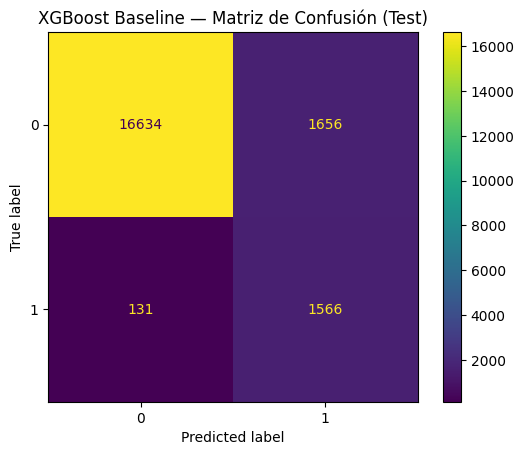

In [120]:
y_pred_train_base = xgb_baseline.predict(X_train)
y_prob_train_base = xgb_baseline.predict_proba(X_train)[:, 1]

y_pred_test_base = xgb_baseline.predict(X_test)
y_prob_test_base = xgb_baseline.predict_proba(X_test)[:, 1]

print('=== TRAIN ===')
print(f'Recall:    {recall_score(y_train, y_pred_train_base):.4f}')
print(f'Precision: {precision_score(y_train, y_pred_train_base):.4f}')
print(f'PR-AUC:    {average_precision_score(y_train, y_prob_train_base):.4f}')

print('\n=== TEST ===')
print(f'Recall:    {recall_score(y_test, y_pred_test_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test_base):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test_base):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_base)
plt.title('XGBoost Baseline — Matriz de Confusión (Test)')
plt.show()

**Análisis del baseline:**

El resultado más llamativo es la **ausencia práctica de overfitting**: la brecha train/test es mínima (Recall 0.9316 → 0.9228, PR-AUC 0.8959 → 0.8893). Esto contrasta radicalmente con el RF Baseline, que memorizaba el conjunto de entrenamiento (Recall train 0.9988 vs test 0.6889). La razón es estructural: boosting construye árboles secuencialmente, cada uno corrigiendo solo los errores del anterior, lo que actúa como una regularización implícita incluso con los hiperparámetros por defecto.

En test, el modelo detecta **1566 de 1697 pacientes diabéticos** (Recall 0.9228), dejando sin detectar únicamente 131 — menos de la mitad que el RF Baseline (528 FN) y menos incluso que el RF con hiperparámetros optimizados (164 FN). A cambio, genera 1656 Falsos Positivos: de cada 3 pacientes que el modelo señala como diabéticos, aproximadamente 1 lo es realmente (Precision 0.4860).

El PR-AUC de **0.8893** ya supera al RF Baseline (0.8587) y es comparable al RF Optimizado (0.8833), con la ventaja de que aquí no se ha realizado ninguna búsqueda de hiperparámetros.

En conjunto, el XGBoost Baseline parte de una posición muy sólida. El margen de mejora con la búsqueda de hiperparámetros no será tan dramático como en el RF, pero podría afinar el balance precisión/recall — en particular reducir los Falsos Positivos sin sacrificar el Recall ya conseguido.

# 8. XGBoost Baseline - Optimización del umbral de clasificación

El baseline obtuvo un Recall ya alto (0.9228) con el umbral por defecto (0.5). Se busca ahora el umbral óptimo sobre las probabilidades calculadas en §7, maximizando el F2-score en train para priorizar el Recall sobre la Precision. El umbral se optimiza en train y se aplica sobre test para evitar data leakage.

In [121]:
thresholds = np.arange(0.1, 0.9, 0.01)

f2_scores_train_base = []
for threshold in thresholds:
    y_pred_t = (y_prob_train_base >= threshold).astype(int)
    f2_scores_train_base.append(fbeta_score(y_train, y_pred_t, beta=2, zero_division=0))

best_threshold_base = thresholds[np.argmax(f2_scores_train_base)]
print(f'Umbral óptimo: {best_threshold_base:.2f}')
print(f'F2 máximo en train: {max(f2_scores_train_base):.4f}')

Umbral óptimo: 0.67
F2 máximo en train: 0.8054


Aplicar umbral óptimo sobre test:

=== TEST CON UMBRAL ÓPTIMO ===
Umbral óptimo (optimizado en train): 0.67
Recall:    0.8409
Precision: 0.6431
PR-AUC:    0.8893


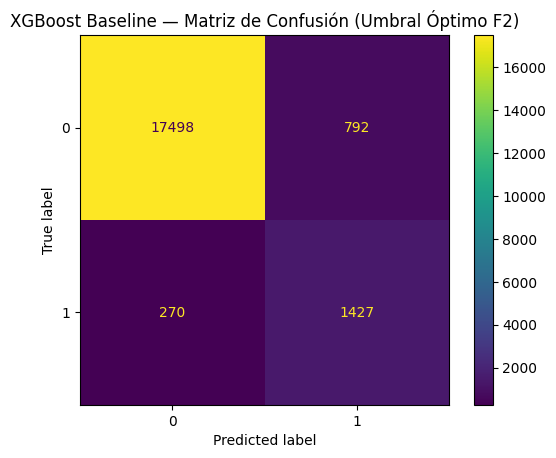

In [122]:
y_pred_optimal_base = (y_prob_test_base >= best_threshold_base).astype(int)

print('=== TEST CON UMBRAL ÓPTIMO ===')
print(f'Umbral óptimo (optimizado en train): {best_threshold_base:.2f}')
print(f'Recall:    {recall_score(y_test, y_pred_optimal_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_optimal_base):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test_base):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal_base)
plt.title('XGBoost Baseline — Matriz de Confusión (Umbral Óptimo F2)')
plt.show()

**Análisis del baseline con umbral optimizado:**

El umbral óptimo encontrado en train es **0.67**, por encima del 0.5 por defecto — la dirección opuesta al RF Baseline (que bajó a 0.42). Esto ocurre porque el XGBoost ya parte de un Recall muy alto (0.9228) con el umbral estándar; el F2 en train mejora siendo más exigente con la predicción positiva, subiendo la Precision sin perder demasiado Recall.

El resultado en test refleja ese intercambio: el Recall baja de 0.9228 a **0.8409** (−8.2 pp) y la Precision sube de 0.4860 a **0.6431** (+15.7 pp). En la matriz de confusión, los Falsos Positivos caen de 1656 a **792** (−864 alarmas falsas), mientras que los Falsos Negativos aumentan de 131 a **270** (+139 diabéticos no detectados).

El F2 máximo en train de **0.8054** es mucho más realista que el 0.9971 del RF Baseline, lo que confirma que XGBoost no memoriza el conjunto de entrenamiento: el rendimiento que estima en train se aproxima bastante a lo que ocurre en test.

En términos clínicos, la elección entre §7 (t=0.5) y §8 (t=0.67) depende del contexto: si el objetivo es no dejar ningún diabético sin detectar, el umbral 0.5 con solo 131 FN es preferible; si se quiere reducir la carga de pruebas de confirmación innecesarias manteniendo un Recall del 84%, el umbral 0.67 ofrece un balance más equilibrado.

# 9. XGBoost con optimización de hiperparámetros

Se definen los hiperparámetros:

In [123]:
xgb_params = {
    'model__n_estimators':     [100, 200, 300, 500],
    'model__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'model__max_depth':        [3, 4, 5, 6, 8],
    'model__subsample':        [0.6, 0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_alpha':        [0, 0.01, 0.1],
    'model__reg_lambda':       [0.5, 1.0, 1.5],
}

Se aplica el pipeline:

Los hiperparámetros explorados por el RandomizedSearchCV y su significado son:

- **n_estimators** [100, 200, 300, 500]: número de rondas de boosting. Más árboles permiten corregir más errores residuales, pero hay rendimientos decrecientes; combinado con `learning_rate` bajo puede mejorar la calibración de probabilidades.
- **learning_rate** [0.01, 0.05, 0.1, 0.2]: factor de reducción aplicado a la contribución de cada árbol. Es el hiperparámetro más importante en boosting: valores bajos requieren más `n_estimators` pero generalizan mejor. Existe un trade-off directo entre ambos.
- **max_depth** [3, 4, 5, 6, 8]: profundidad máxima de cada árbol. Boosting funciona bien con árboles poco profundos (3–6) porque la complejidad se construye de forma aditiva a través de múltiples árboles, no dentro de un único árbol.
- **subsample** [0.6, 0.7, 0.8, 1.0]: fracción de filas del conjunto de entrenamiento usada para construir cada árbol. Introduce aleatoriedad por filas, diversificando el ensemble. Equivalente a `max_samples` en Random Forest.
- **colsample_bytree** [0.6, 0.8, 1.0]: fracción de features seleccionadas aleatoriamente antes de construir cada árbol. Introduce aleatoriedad por columnas, evitando que el modelo dependa siempre de las mismas variables dominantes. Equivalente a `max_features` en Random Forest.
- **reg_alpha** [0, 0.01, 0.1]: regularización L1 sobre los pesos de las hojas. Penaliza valores absolutos altos, induciendo sparsity (hojas con peso cero). No existe en Random Forest.
- **reg_lambda** [0.5, 1.0, 1.5]: regularización L2 sobre los pesos de las hojas. Penaliza valores grandes suavizando las predicciones de cada hoja. El default de XGBoost es 1.0; valores mayores aumentan la regularización.

In [124]:
xgb_pipeline = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

Se configura el RandomizedSearchCV:

In [125]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Entrenamiento:

In [126]:
xgb_search.fit(X_train, y_train)
print('Mejores parámetros:', xgb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'model__subsample': 0.6, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


Los mejores hiperparámetros encontrados son:

- **n_estimators=500 + learning_rate=0.05**: la búsqueda reduce el learning_rate a la mitad respecto al baseline (0.1→0.05) y duplica el número de árboles (100→500). Es el trade-off clásico de boosting: pasos más pequeños requieren más iteraciones pero generalizan mejor.
- **max_depth=3**: el valor mínimo explorado. Los árboles más superficiales son el estilo canónico de gradient boosting: la complejidad se construye de forma aditiva a través de muchos árboles, no dentro de un único árbol profundo.
- **subsample=0.6** y **colsample_bytree=0.6**: los valores más agresivos del espacio de búsqueda en ambos parámetros. Cada árbol ve solo el 60% de las filas y el 60% de las features, maximizando la diversidad del ensemble.
- **reg_alpha=0.1** y **reg_lambda=1.5**: los valores más altos de regularización explorados. Combinados con árboles superficiales y alta estocásticidad, la búsqueda apunta hacia el modelo más regularizado posible dentro del espacio definido.

El patrón es claro: el RandomizedSearchCV selecciona la combinación de máxima regularización disponible. Sin embargo, como muestra la evaluación, esta regularización adicional no aporta mejora medible sobre el baseline — lo que confirma que XGBoost ya era robusto desde el principio y que el espacio de mejora era prácticamente inexistente.

Resultados por fold. Muestra las 3 mejores combinaciones de hiperparámetros ordenadas por PR-AUC medio descendente:

In [127]:
results = pd.DataFrame(xgb_search.cv_results_)
results[[
    'param_model__n_estimators',
    'param_model__learning_rate',
    'param_model__max_depth',
    'param_model__subsample',
    'param_model__colsample_bytree',
    'param_model__reg_alpha',
    'param_model__reg_lambda',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('mean_test_score', ascending=False).head(3)

,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,param_model__colsample_bytree,param_model__reg_alpha,param_model__reg_lambda,mean_test_score,std_test_score,rank_test_score
1,500,0.05,3,0.6,0.6,0.1,1.5,0.887945,0.003947,1
0,200,0.10,3,0.8,1.0,0.1,1.5,0.887834,0.004286,2
7,300,0.10,3,0.8,0.8,0.1,1.5,0.887358,0.004289,3


Evaluación final train/test:

=== TRAIN ===
Recall:    0.9271
Precision: 0.4797
PR-AUC:    0.8947

=== TEST ===
Recall:    0.9240
Precision: 0.4844
PR-AUC:    0.8892


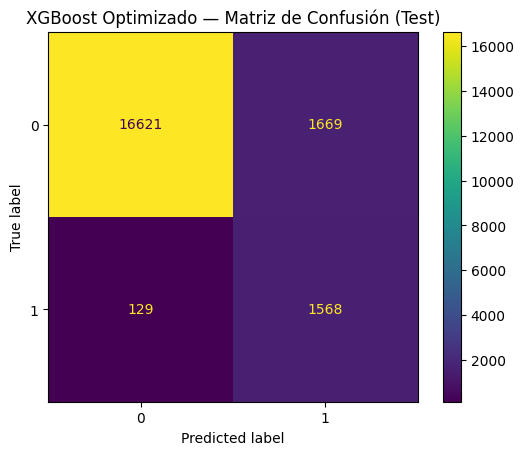

In [128]:
y_pred_train = xgb_search.predict(X_train)
y_prob_train = xgb_search.predict_proba(X_train)[:, 1]

y_pred_test = xgb_search.predict(X_test)
y_prob_test = xgb_search.predict_proba(X_test)[:, 1]

print('=== TRAIN ===')
print(f'Recall:    {recall_score(y_train, y_pred_train):.4f}')
print(f'Precision: {precision_score(y_train, y_pred_train):.4f}')
print(f'PR-AUC:    {average_precision_score(y_train, y_prob_train):.4f}')

print('\n=== TEST ===')
print(f'Recall:    {recall_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title('XGBoost Optimizado — Matriz de Confusión (Test)')
plt.show()

**Análisis del modelo optimizado:**

La búsqueda de hiperparámetros produce una mejora prácticamente nula respecto al baseline: el PR-AUC apenas varía (0.8893 → 0.8892), el Recall sube de 0.9228 a **0.9240** (+0.1 pp) y los Falsos Negativos se reducen de 131 a **129** (−2 pacientes). Las diferencias están dentro del margen de ruido estadístico.

Esto contrasta radicalmente con el Random Forest, donde la optimización fue imprescindible: el RF Baseline tenía un Recall de 0.6889 y necesitó regularización explícita (`max_depth`, `min_samples_leaf`) para llegar a 0.9034. En XGBoost, la arquitectura de boosting ya actúa como regularización implícita desde el principio — cada árbol corrige solo los errores residuales del anterior, lo que limita de forma natural el sobreajuste sin necesidad de ajuste manual.

El overfitting sigue siendo mínimo (Recall train 0.9271 vs test 0.9240), confirmando que los hiperparámetros por defecto de XGBoost ya están cerca del óptimo para este dataset. En este caso, las 30 iteraciones del RandomizedSearchCV no encuentran una combinación significativamente mejor porque el espacio de mejora era pequeño desde el inicio.

## Feature Importance - Shap Values

In [129]:
best_pipeline_xgb = xgb_search.best_estimator_
smoking_merger_fit = best_pipeline_xgb.named_steps['smoking_merger']
preprocessor_fit   = best_pipeline_xgb.named_steps['preprocessor']
best_xgb           = best_pipeline_xgb.named_steps['model']

Xp_train = preprocessor_fit.transform(smoking_merger_fit.transform(X_train))
fnames   = list(preprocessor_fit.get_feature_names_out())

X_shap = Xp_train[:500]

explainer = shap.TreeExplainer(best_xgb)
sv = explainer.shap_values(X_shap)
if isinstance(sv, list):
    shap_class1 = sv[1]
elif sv.ndim == 3:
    shap_class1 = sv[:, :, 1]
else:
    shap_class1 = sv

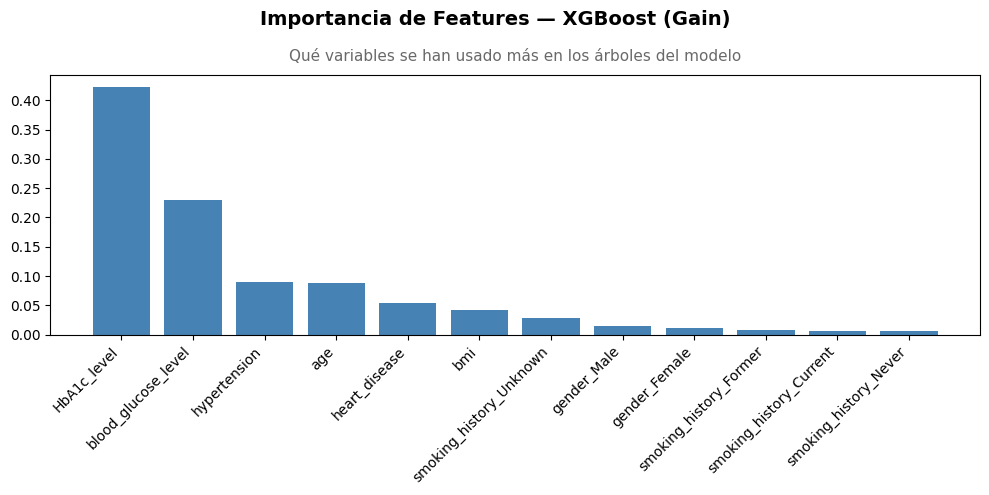

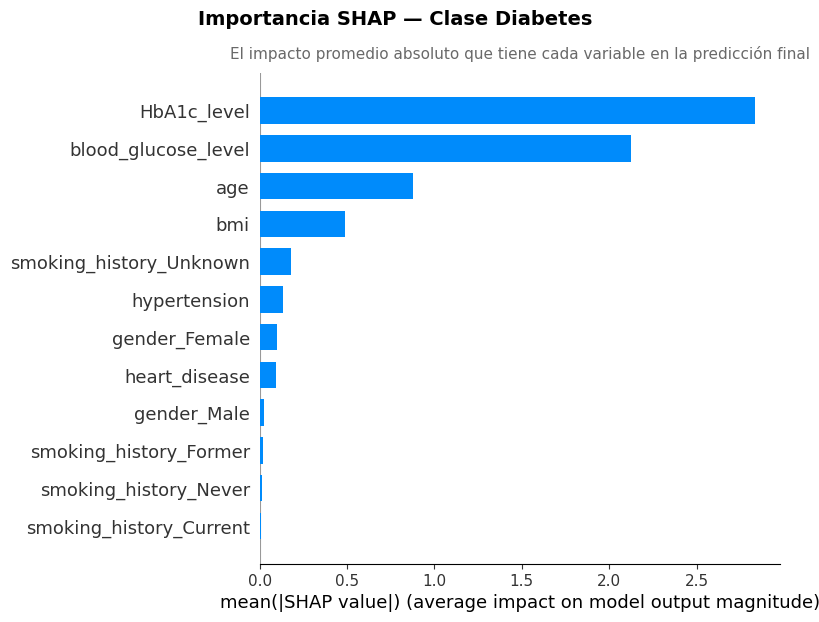

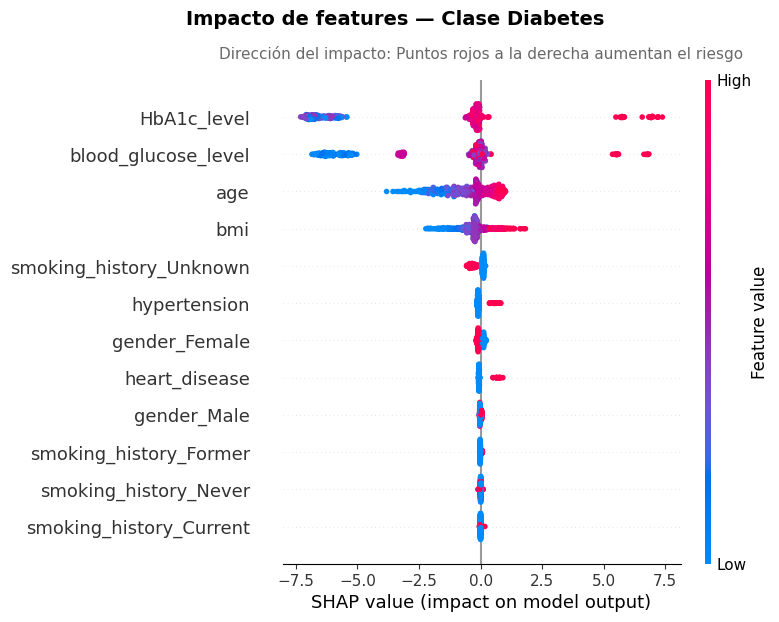

In [130]:
# --- Feature Importance nativa (XGBoost gain) ---
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(fnames)), importances[indices], color='steelblue')
plt.xticks(range(len(fnames)), [fnames[i] for i in indices], rotation=45, ha='right')
plt.suptitle('Importancia de Features — XGBoost (Gain)', fontsize=14, fontweight='bold')
plt.title('Qué variables se han usado más en los árboles del modelo', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Barras ---
shap.summary_plot(shap_class1, X_shap, feature_names=fnames, plot_type='bar', show=False)
plt.suptitle('Importancia SHAP — Clase Diabetes', fontsize=14, fontweight='bold')
plt.title('El impacto promedio absoluto que tiene cada variable en la predicción final', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Puntos (Beeswarm) ---
shap.summary_plot(shap_class1, X_shap, feature_names=fnames, show=False)
plt.suptitle('Impacto de features — Clase Diabetes', fontsize=14, fontweight='bold')
plt.title('Dirección del impacto: Puntos rojos a la derecha aumentan el riesgo', fontsize=11, color='dimgrey', pad=15)
plt.tight_layout()
plt.show()

# 10. XGBoost con optimización de hiperparámetros y umbral de clasificación

El modelo optimizado en §9 parte de un Recall alto (0.9240) con el umbral por defecto (0.5). Se busca ahora el umbral que maximiza el F2-score sobre las probabilidades de train, y se aplica sobre test para evitar data leakage.

In [131]:
thresholds = np.arange(0.1, 0.9, 0.01)

f2_scores_train = []
for threshold in thresholds:
    y_pred_t = (y_prob_train >= threshold).astype(int)
    f2_scores_train.append(fbeta_score(y_train, y_pred_t, beta=2, zero_division=0))

best_threshold = thresholds[np.argmax(f2_scores_train)]
print(f'Umbral óptimo: {best_threshold:.2f}')
print(f'F2 máximo en train: {max(f2_scores_train):.4f}')

Umbral óptimo: 0.65
F2 máximo en train: 0.8055


Aplicar umbral óptimo sobre test:

=== TEST CON UMBRAL ÓPTIMO ===
Umbral óptimo (optimizado en train): 0.65
Recall:    0.8556
Precision: 0.6173
PR-AUC:    0.8892


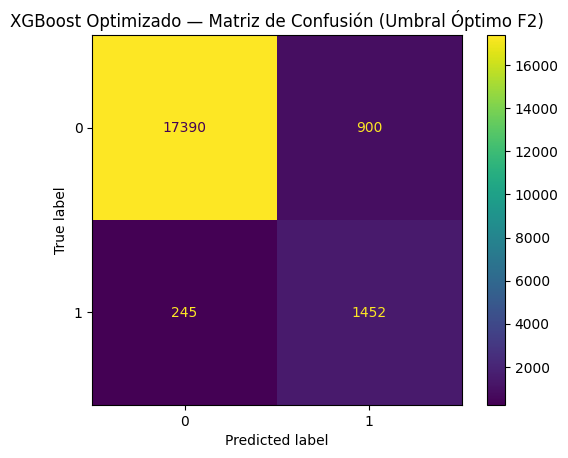

In [132]:
y_pred_optimal = (y_prob_test >= best_threshold).astype(int)

print('=== TEST CON UMBRAL ÓPTIMO ===')
print(f'Umbral óptimo (optimizado en train): {best_threshold:.2f}')
print(f'Recall:    {recall_score(y_test, y_pred_optimal):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_optimal):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal)
plt.title('XGBoost Optimizado — Matriz de Confusión (Umbral Óptimo F2)')
plt.show()

**Análisis del modelo optimizado con umbral ajustado:**

El umbral óptimo es **0.65**, ligeramente inferior al 0.67 del §8 (baseline con umbral). El resultado es un balance algo más favorable que en §8: el Recall sube de 0.8409 a **0.8556** (+1.5 pp) con una Precision ligeramente inferior (0.6431 → 0.6173), y los Falsos Negativos se reducen de 270 a **245** (−25 diabéticos no detectados).

El F2 máximo en train de **0.8055** es prácticamente idéntico al del §8 (0.8054), lo que confirma una vez más que el modelo optimizado y el baseline son equivalentes en rendimiento real — la búsqueda de hiperparámetros no aportó diferencia significativa.

Comparando los cuatro modelos XGBoost, el patrón es claro: las dos variantes con umbral por defecto (§7 y §9) ofrecen el Recall más alto (~0.923, ~130 FN) a costa de más Falsos Positivos (~1660); las dos con umbral optimizado (§8 y §10) reducen los FP a ~800–900 manteniendo un Recall del 84–86%. La elección entre ambas estrategias depende del contexto clínico: priorizar detección máxima o reducir la carga de confirmaciones innecesarias.

# 11. Guardar y cargar los modelos

## 11.1. Guardar:

In [136]:
xgb_baseline_loaded  = joblib.load('artifacts_xgb/xgb_baseline.pkl')
xgb_optimized_loaded = joblib.load('artifacts_xgb/xgb_optimized.pkl')

thresholds_loaded    = joblib.load('artifacts_xgb/thresholds.pkl')
best_threshold_base  = thresholds_loaded['best_threshold_base']
best_threshold       = thresholds_loaded['best_threshold']

y_prob_train_base = np.load('artifacts_xgb/y_prob_train_base.npy')
y_prob_test_base  = np.load('artifacts_xgb/y_prob_test_base.npy')
y_prob_train      = np.load('artifacts_xgb/y_prob_train.npy')
y_prob_test       = np.load('artifacts_xgb/y_prob_test.npy')

print('Cargado desde artifacts_xgb/')

Cargado desde artifacts_xgb/


## 11.2. Cargar:

In [135]:
os.makedirs('artifacts_xgb', exist_ok=True)

joblib.dump(xgb_baseline,              'artifacts_xgb/xgb_baseline.pkl')
joblib.dump(xgb_search.best_estimator_, 'artifacts_xgb/xgb_optimized.pkl')
joblib.dump({
    'best_threshold_base': best_threshold_base,
    'best_threshold':      best_threshold
}, 'artifacts_xgb/thresholds.pkl')

np.save('artifacts_xgb/y_prob_train_base.npy', y_prob_train_base)
np.save('artifacts_xgb/y_prob_test_base.npy',  y_prob_test_base)
np.save('artifacts_xgb/y_prob_train.npy',      y_prob_train)
np.save('artifacts_xgb/y_prob_test.npy',       y_prob_test)

print('Guardado en artifacts_xgb/')

Guardado en artifacts_xgb/


# 12. Curva Precision-Recall entre XGBoost Baseline y XGBoost Optimizado

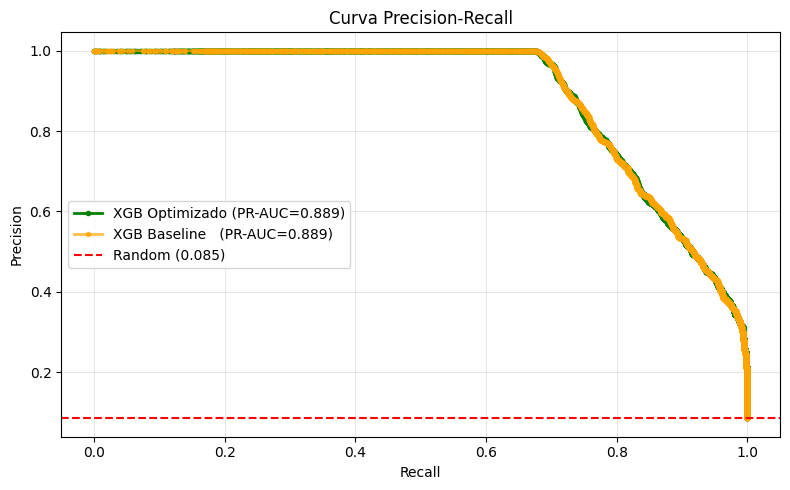

Guardado: artifacts_xgb/xgb_pr_curve.png


In [137]:
pr_opt,  re_opt,  _ = precision_recall_curve(y_test, y_prob_test)
pr_base, re_base, _ = precision_recall_curve(y_test, y_prob_test_base)

pr_auc_opt  = average_precision_score(y_test, y_prob_test)
pr_auc_base = average_precision_score(y_test, y_prob_test_base)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(re_opt,  pr_opt,  marker='.', label=f'XGB Optimizado (PR-AUC={pr_auc_opt:.3f})',  color='green',  lw=2)
ax.plot(re_base, pr_base, marker='.', label=f'XGB Baseline   (PR-AUC={pr_auc_base:.3f})', color='orange', lw=2, alpha=0.7)
ax.axhline(y=y_test.mean(), color='red', ls='--', label=f'Random ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts_xgb/xgb_pr_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Guardado: artifacts_xgb/xgb_pr_curve.png')

# 13. Threshold Tuning

Threshold óptimo (optimizado en train): 0.65
  Precision: 0.6173
  Recall:    0.8556
  F2:        0.7943
  F1:        0.7172


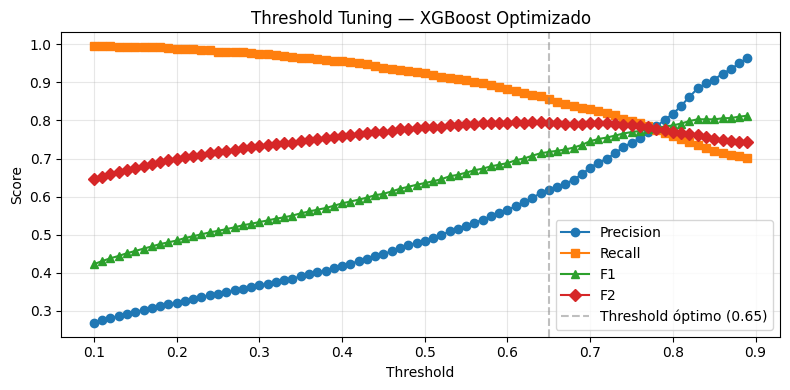


Comparación: default (0.5) vs óptimo (0.65)
  Recall default:    0.9240  ->  óptimo: 0.8556
  Precision default: 0.4844  ->  óptimo: 0.6173


In [138]:
thresholds_plot = np.arange(0.1, 0.9, 0.01)
scores = []
for t in thresholds_plot:
    y_pred_t = (y_prob_test >= t).astype(int)
    scores.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    })
df_t = pd.DataFrame(scores)

best_row = df_t.iloc[(df_t['threshold'] - best_threshold).abs().argsort()[:1]]
print(f'Threshold óptimo (optimizado en train): {best_threshold:.2f}')
print(f'  Precision: {best_row["precision"].values[0]:.4f}')
print(f'  Recall:    {best_row["recall"].values[0]:.4f}')
print(f'  F2:        {best_row["f2"].values[0]:.4f}')
print(f'  F1:        {best_row["f1"].values[0]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_t['threshold'], df_t['precision'], label='Precision', marker='o')
ax.plot(df_t['threshold'], df_t['recall'],    label='Recall',    marker='s')
ax.plot(df_t['threshold'], df_t['f1'],        label='F1',        marker='^')
ax.plot(df_t['threshold'], df_t['f2'],        label='F2',        marker='D')
ax.axvline(x=best_threshold, color='gray', ls='--', alpha=0.5,
           label=f'Threshold óptimo ({best_threshold:.2f})')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Tuning — XGBoost Optimizado')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts_xgb/xgb_threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

recall_default    = recall_score(y_test, (y_prob_test >= 0.5).astype(int))
precision_default = precision_score(y_test, (y_prob_test >= 0.5).astype(int))
print(f'\nComparación: default (0.5) vs óptimo ({best_threshold:.2f})')
print(f'  Recall default:    {recall_default:.4f}  ->  óptimo: {best_row["recall"].values[0]:.4f}')
print(f'  Precision default: {precision_default:.4f}  ->  óptimo: {best_row["precision"].values[0]:.4f}')

# 14. Comparación: Baseline vs Optimizado

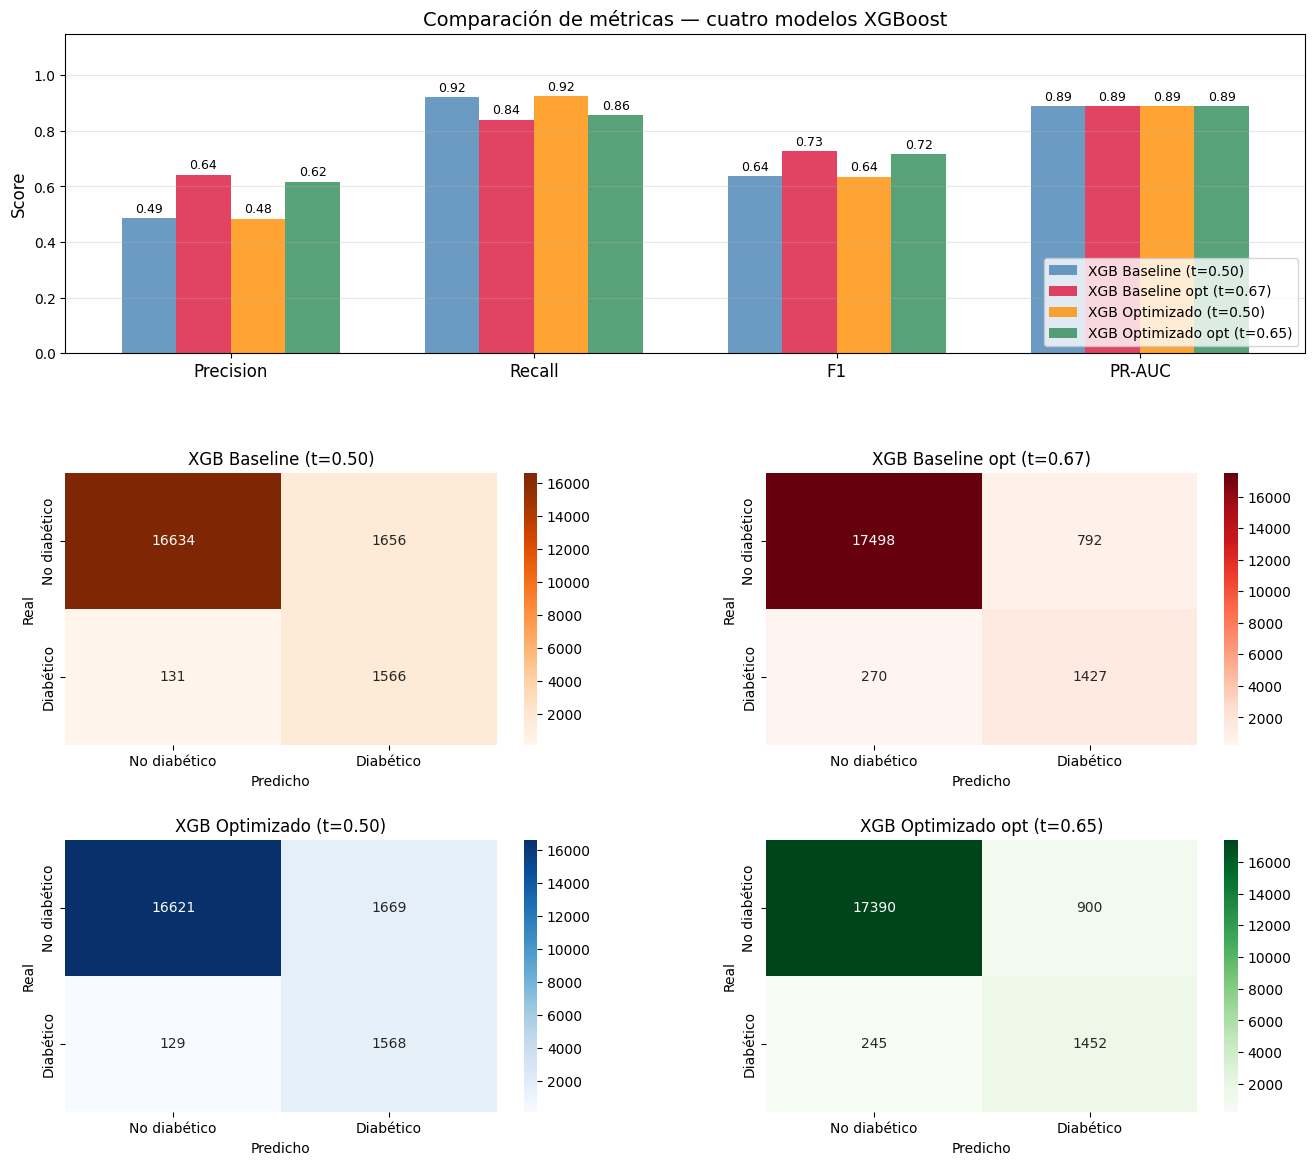

Guardado: artifacts_xgb/xgb_comparison.png


In [139]:
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_base_05  = (y_prob_test_base >= 0.5).astype(int)
y_pred_base_opt = (y_prob_test_base >= best_threshold_base).astype(int)
y_pred_opt_05   = (y_prob_test >= 0.5).astype(int)
y_pred_opt      = (y_prob_test >= best_threshold).astype(int)

def get_metrics(y_true, y_pred, y_score):
    return {
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'PR-AUC':    average_precision_score(y_true, y_score),
    }

base_metrics     = get_metrics(y_test, y_pred_base_05,  y_prob_test_base)
base_opt_metrics = get_metrics(y_test, y_pred_base_opt, y_prob_test_base)
opt05_metrics    = get_metrics(y_test, y_pred_opt_05,   y_prob_test)
opt_metrics      = get_metrics(y_test, y_pred_opt,      y_prob_test)

cm_base     = confusion_matrix(y_test, y_pred_base_05)
cm_base_opt = confusion_matrix(y_test, y_pred_base_opt)
cm_opt_05   = confusion_matrix(y_test, y_pred_opt_05)
cm_opt      = confusion_matrix(y_test, y_pred_opt)

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.25)

ax_bar = fig.add_subplot(gs[0])
metrics_names = ['Precision', 'Recall', 'F1', 'PR-AUC']
x = np.arange(len(metrics_names))
w = 0.18

ax_bar.bar(x - 1.5*w, [base_metrics[m]     for m in metrics_names], w, label='XGB Baseline (t=0.50)',                           color='steelblue',  alpha=0.8)
ax_bar.bar(x - 0.5*w, [base_opt_metrics[m] for m in metrics_names], w, label=f'XGB Baseline opt (t={best_threshold_base:.2f})', color='crimson',    alpha=0.8)
ax_bar.bar(x + 0.5*w, [opt05_metrics[m]    for m in metrics_names], w, label='XGB Optimizado (t=0.50)',                         color='darkorange', alpha=0.8)
ax_bar.bar(x + 1.5*w, [opt_metrics[m]      for m in metrics_names], w, label=f'XGB Optimizado opt (t={best_threshold:.2f})',    color='seagreen',   alpha=0.8)

ax_bar.set_xticks(x); ax_bar.set_xticklabels(metrics_names, fontsize=12)
ax_bar.set_ylim([0, 1.15]); ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_title('Comparación de métricas — cuatro modelos XGBoost', fontsize=14)
ax_bar.legend(fontsize=10, loc='lower right'); ax_bar.grid(axis='y', alpha=0.3)
for bars in ax_bar.containers:
    ax_bar.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)

gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], hspace=0.35, wspace=0.3)
labels = ['No diabético', 'Diabético']

for ax, cm, title, cmap in zip(
    [fig.add_subplot(gs_bottom[0, 0]), fig.add_subplot(gs_bottom[0, 1]),
     fig.add_subplot(gs_bottom[1, 0]), fig.add_subplot(gs_bottom[1, 1])],
    [cm_base, cm_base_opt, cm_opt_05, cm_opt],
    [f'XGB Baseline (t=0.50)', f'XGB Baseline opt (t={best_threshold_base:.2f})',
     f'XGB Optimizado (t=0.50)', f'XGB Optimizado opt (t={best_threshold:.2f})'],
    ['Oranges', 'Reds', 'Blues', 'Greens']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set_title(title, fontsize=12); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

plt.savefig('artifacts_xgb/xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: artifacts_xgb/xgb_comparison.png')

# 15. XGBoost sin variables altamente explicativas

El objetivo de este apartado es evaluar el rendimiento de XGBoost **sin las dos variables más informativas del dataset**: `HbA1c_level` y `blood_glucose_level`. Al igual que en el notebook de Random Forest, la pregunta clínica es si el modelo puede predecir diabetes de forma útil usando únicamente variables de estilo de vida y factores de riesgo clásicos — edad, IMC, hipertensión, historial de tabaquismo — disponibles sin necesidad de analítica de laboratorio.

Se aplica la misma metodología que en el apartado 9 (RandomizedSearchCV con StratifiedKFold y PR-AUC como métrica) y el mismo espacio de búsqueda `xgb_params` para que la comparación con el modelo completo sea directa.

Se definen los hiperparámetros:

Se reutiliza el mismo espacio de búsqueda `xgb_params` definido en §9 para facilitar la comparación directa entre los dos modelos.

Se aplica el pipeline:

In [140]:
X_train_red = X_train.drop(columns=['HbA1c_level', 'blood_glucose_level'])
X_test_red  = X_test.drop(columns=['HbA1c_level', 'blood_glucose_level'])

preprocessor_red = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), ['gender', 'smoking_history']),
], remainder='passthrough', verbose_feature_names_out=False)

xgb_pipeline_red = Pipeline([
    ('smoking_merger', SmokingMerger()),
    ('preprocessor', preprocessor_red),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

Se configura el RandomizedSearchCV:

In [141]:
cv_red = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search_red = RandomizedSearchCV(
    xgb_pipeline_red,
    param_distributions=xgb_params,
    n_iter=30,
    scoring='average_precision',
    cv=cv_red,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

Entrenamiento:

In [142]:
xgb_search_red.fit(X_train_red, y_train)
print('Mejores parámetros:', xgb_search_red.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros: {'model__subsample': 0.6, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.1, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


Resultados por fold. Muestra las 3 mejores combinaciones de hiperparámetros ordenadas por PR-AUC medio descendente:

In [143]:
results_red = pd.DataFrame(xgb_search_red.cv_results_)
results_red[[
    'param_model__n_estimators',
    'param_model__learning_rate',
    'param_model__max_depth',
    'param_model__subsample',
    'param_model__colsample_bytree',
    'param_model__reg_alpha',
    'param_model__reg_lambda',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values('mean_test_score', ascending=False).head(3)

,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__subsample,param_model__colsample_bytree,param_model__reg_alpha,param_model__reg_lambda,mean_test_score,std_test_score,rank_test_score
1,500,0.05,3,0.6,0.6,0.1,1.5,0.325246,0.012839,1
0,200,0.10,3,0.8,1.0,0.1,1.5,0.325015,0.012251,2
7,300,0.10,3,0.8,0.8,0.1,1.5,0.324884,0.011972,3


Evaluación final train/test:

=== TRAIN ===
Recall:    0.8019
Precision: 0.2103
PR-AUC:    0.3353

=== TEST ===
Recall:    0.8097
Precision: 0.2132
PR-AUC:    0.3209


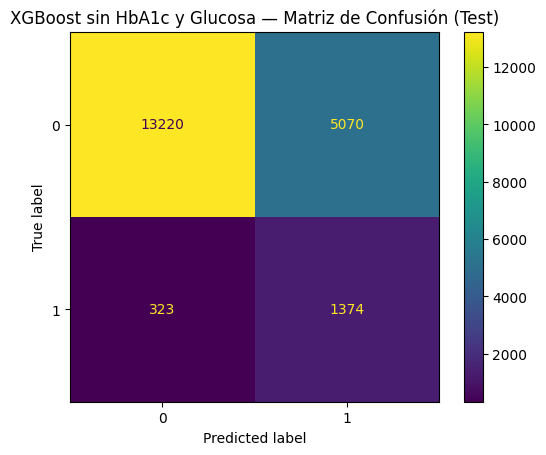

In [144]:
y_pred_train_red = xgb_search_red.predict(X_train_red)
y_prob_train_red = xgb_search_red.predict_proba(X_train_red)[:, 1]

y_pred_test_red  = xgb_search_red.predict(X_test_red)
y_prob_test_red  = xgb_search_red.predict_proba(X_test_red)[:, 1]

print('=== TRAIN ===')
print(f'Recall:    {recall_score(y_train, y_pred_train_red):.4f}')
print(f'Precision: {precision_score(y_train, y_pred_train_red):.4f}')
print(f'PR-AUC:    {average_precision_score(y_train, y_prob_train_red):.4f}')

print('\n=== TEST ===')
print(f'Recall:    {recall_score(y_test, y_pred_test_red):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test_red):.4f}')
print(f'PR-AUC:    {average_precision_score(y_test, y_prob_test_red):.4f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_red)
plt.title('XGBoost sin HbA1c y Glucosa — Matriz de Confusión (Test)')
plt.show()

## Feature Importance - Shap Values

In [145]:
best_pipeline_red      = xgb_search_red.best_estimator_
smoking_merger_red_fit = best_pipeline_red.named_steps['smoking_merger']
preprocessor_red_fit   = best_pipeline_red.named_steps['preprocessor']
best_xgb_red           = best_pipeline_red.named_steps['model']

Xp_train_red = preprocessor_red_fit.transform(smoking_merger_red_fit.transform(X_train_red))
fnames_red   = list(preprocessor_red_fit.get_feature_names_out())

X_shap_red = Xp_train_red[:500]

explainer_red = shap.TreeExplainer(best_xgb_red)
sv_red = explainer_red.shap_values(X_shap_red)
if isinstance(sv_red, list):
    shap_class1_red = sv_red[1]
elif sv_red.ndim == 3:
    shap_class1_red = sv_red[:, :, 1]
else:
    shap_class1_red = sv_red

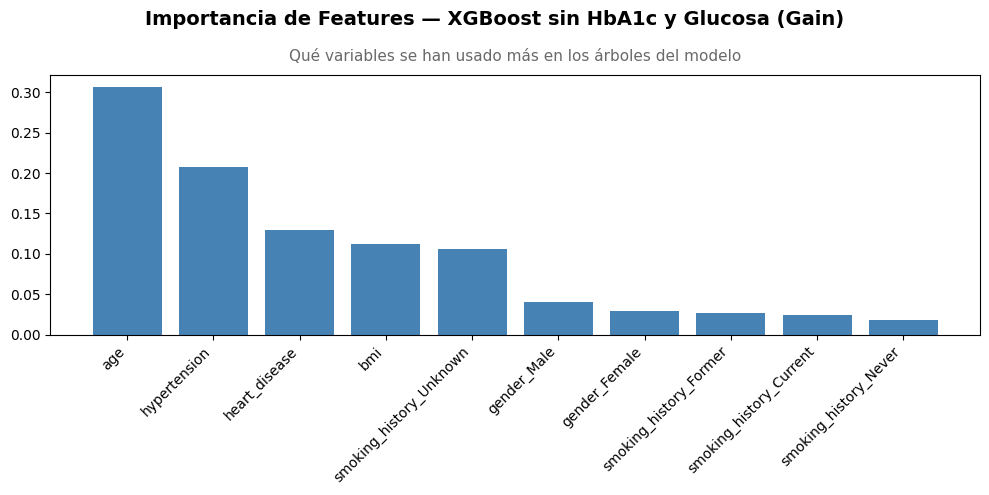

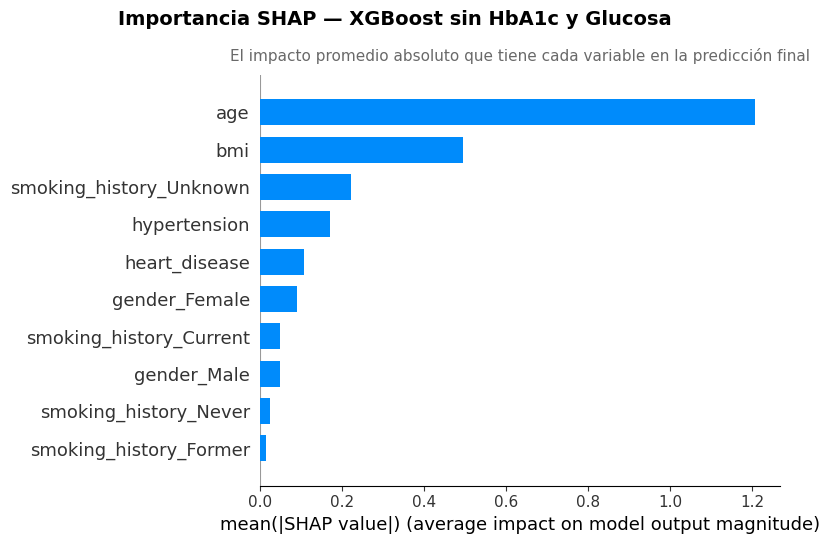

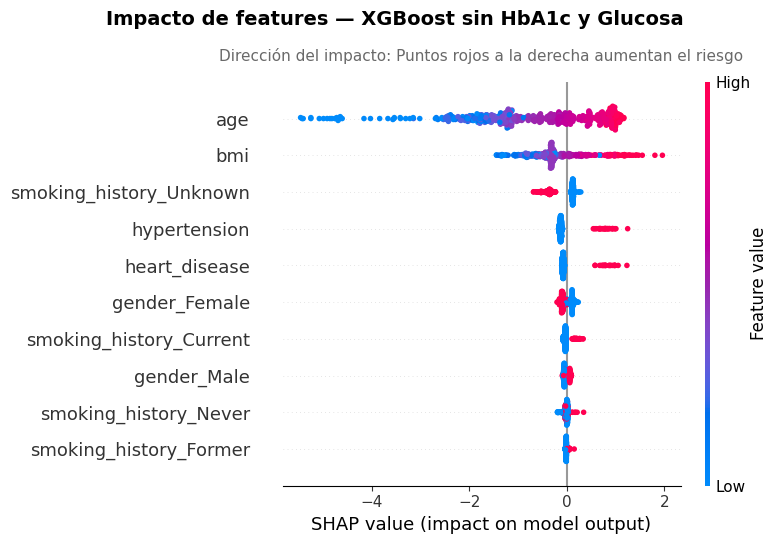

In [146]:
# --- Feature Importance nativa (XGBoost gain) ---
importances_red = best_xgb_red.feature_importances_
indices_red = np.argsort(importances_red)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(fnames_red)), importances_red[indices_red], color='steelblue')
plt.xticks(range(len(fnames_red)), [fnames_red[i] for i in indices_red], rotation=45, ha='right')
plt.suptitle('Importancia de Features — XGBoost sin HbA1c y Glucosa (Gain)', fontsize=14, fontweight='bold')
plt.title('Qué variables se han usado más en los árboles del modelo', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Barras ---
shap.summary_plot(shap_class1_red, X_shap_red, feature_names=fnames_red, plot_type='bar', show=False)
plt.suptitle('Importancia SHAP — XGBoost sin HbA1c y Glucosa', fontsize=14, fontweight='bold')
plt.title('El impacto promedio absoluto que tiene cada variable en la predicción final', fontsize=11, color='dimgrey', pad=10)
plt.tight_layout()
plt.show()

# --- SHAP Gráfico de Puntos (Beeswarm) ---
shap.summary_plot(shap_class1_red, X_shap_red, feature_names=fnames_red, show=False)
plt.suptitle('Impacto de features — XGBoost sin HbA1c y Glucosa', fontsize=14, fontweight='bold')
plt.title('Dirección del impacto: Puntos rojos a la derecha aumentan el riesgo', fontsize=11, color='dimgrey', pad=15)
plt.tight_layout()
plt.show()